# Fraud Detection — EDA & Preprocessing

Notebook được tổ chức theo các bước chuẩn:

1. Setup môi trường
2. Load dữ liệu
3. Định nghĩa nhóm cột (drop / datetime / categorical / numeric / target)
4. Kiểm tra chất lượng dữ liệu (null, dtype, target balance)
5. EDA — thời gian (giờ, ngày trong tuần, tháng, tuổi)
6. EDA — categorical (category, gender, merchant, job)
7. EDA — numeric (phân phối, tương quan với target)
8. EDA — địa lý (khoảng cách khách hàng ↔ merchant)
9. Tổng hợp insight từ EDA
10. Feature engineering & encoding
11. Train / test split (chuẩn bị cho modeling)


## 1. Setup


In [5]:
! pip install matplotlib seaborn scikit-learn xgboost lightgbm catboost optuna imbalanced-learn pyarrow fastparquet --quiet

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow


from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


## 2. Load dữ liệu


In [7]:
df = pd.read_csv("data.csv")
# Tạo thư mục lưu chunk
out_dir = Path("data_chunks_16")
out_dir.mkdir(exist_ok=True)

# 1. Sắp xếp toàn bộ df theo thời gian
df_sorted = df.sort_values("unix_time").reset_index(drop=True)

# 2. Chia thành đúng 40 phần
index_chunks = np.array_split(df_sorted.index, 16)

# 3. Lưu từng phần
for i, idx in enumerate(index_chunks, start=1):
    chunk = df_sorted.loc[idx]
    file_path = out_dir / f"transactions_time_sorted_part_{i:02d}.parquet"
    chunk.to_parquet(file_path, index=False)
    print(f"Saved {file_path} | rows = {len(chunk):,}")

Saved data_chunks_16\transactions_time_sorted_part_01.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_02.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_03.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_04.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_05.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_06.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_07.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_08.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_09.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_10.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_11.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_12.parquet | rows = 536,266
Saved data_chunks_16\transactions_time_sorted_part_1

In [8]:
DATA_PATH = "data_chunks_16/transactions_time_sorted_part_01.parquet"
df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()


(536266, 44)


,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,profile,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
0,139-28-2445,6568437428214147,Nancy,Nelson,F,577 Brown Green,Tempe,AZ,85283,33.3665,-111.9312,167311,"Programmer, multimedia",1982-11-23,679112600444,adults_2550_female_urban.json,fb19a5581c3b412192017d50b12ee9bb,2022-05-07,00:00:01,1651878001,gas_transport,201.50,0,fraud_Huels-Nolan,34.142654,-112.261819,0,3,12,15705,14,0,5,1,86.23,60.71,5.96,2325.40,52733.35,995492.71,2,4,5,11
1,073-16-3406,4231871974074,Timothy,Day,M,35740 Hector Park Apt. 297,Kennesaw,GA,30144,34.0287,-84.6047,92645,"Surveyor, land/geomatics",1993-03-29,938334753207,adults_2550_male_urban.json,e3278a710266847dfe714692a32315cb,2022-05-07,00:00:01,1651878001,gas_transport,62.75,0,"fraud_Raynor, Reinger and Hagenes",34.411783,-84.390002,5,7,14,35560,9,0,5,1,83.94,65.99,56.32,4349.77,76889.65,186009.25,7,7,15,36
2,678-29-6606,373212827595927,Dawn,Reyes,F,926 Williams Estate,Castaic,CA,91384,34.4827,-118.6254,29855,Dealer,1966-05-02,700841908718,adults_50up_female_urban.json,b957bc65f3f9d2a6f62aa92cd164d613,2022-05-07,00:00:01,1651878001,gas_transport,113.85,0,fraud_Huels-Hahn,34.841774,-119.491011,2,5,15,1832,19,0,5,1,72.37,67.78,1.32,291.01,56813.71,902029.82,4,13,23,41
3,486-53-8231,676285683501,Heather,Holloway,F,4027 Cox Roads,Federal Way,WA,98003,47.3203,-122.3117,91661,Recycling officer,1999-08-25,58740346422,young_adults_female_urban.json,773e193cab78a0a6d1248456f01834a9,2022-05-07,00:00:02,1651878002,gas_transport,68.40,0,"fraud_Zieme, Bode and Dooley",48.080048,-121.759237,5,9,15,2758,4,0,5,1,75.09,8.34,68.24,339.39,8452.89,33782.03,7,14,18,34
4,796-87-4086,4042585386830,Victoria,Martinez,F,359 Sean Views,Burlington,NC,27217,36.1288,-79.4114,75761,Medical illustrator,1983-08-10,259422320923,adults_2550_female_urban.json,9d211220e99f2c7d122228f80543fcea,2022-05-07,00:00:03,1651878003,gas_transport,32.02,0,fraud_Harber Inc,37.035747,-79.861097,4,6,11,23394,12,0,5,1,35.91,8.70,46.24,1567.87,91330.85,143157.76,4,15,22,42


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 536266 entries, 0 to 536265
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ssn                         536266 non-null  str    
 1   cc_num                      536266 non-null  int64  
 2   first                       536266 non-null  str    
 3   last                        536266 non-null  str    
 4   gender                      536266 non-null  str    
 5   street                      536266 non-null  str    
 6   city                        536266 non-null  str    
 7   state                       536266 non-null  str    
 8   zip                         536266 non-null  int64  
 9   lat                         536266 non-null  float64
 10  long                        536266 non-null  float64
 11  city_pop                    536266 non-null  int64  
 12  job                         536266 non-null  str    
 13  dob                      

In [10]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ssn,536266,8757,435-43-7248,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,536266.0,NaN,NaN,NaN,371037718726458816.0,1235612140001626112.0,60400268763.0,38653934049224.0,3508188659944007.0,4557486605239086.0,4999684803221814272.0
first,536266,659,Michael,11847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,536266,979,Smith,12495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,536266,2,F,269838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,536266,8757,986 Jody Curve,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,536266,3449,Houston,5103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,536266,51,CA,64573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,536266.0,NaN,NaN,NaN,51563.875866,29716.86088,1002.0,27896.0,48197.0,78247.0,99833.0
lat,536266.0,NaN,NaN,NaN,37.436974,5.228083,19.4386,33.8193,38.4069,41.1139,64.8544


## 3. Định nghĩa nhóm cột

Phân loại cột theo vai trò trong modeling. Lý do:

- **PII / ID** (`ssn`, `first`, `last`, `street`, `acct_num`, `cc_num`, `trans_num`,
  `profile`, `city`, `state`): không có giá trị tổng quát hóa, hoặc rò rỉ thông tin cá nhân.
- **Datetime** (`dob`, `trans_date`, `trans_time`): cần tách thành feature số (giờ, ngày trong tuần, tuổi).
- **Categorical** (`gender`, `category`, `merchant`, `job`): cần encoding.
- **Numeric**: dùng trực tiếp, có thể cần scaling cho mô hình tuyến tính.
- **Target**: `is_fraud`.


In [11]:
DROP_COLS = [
    "ssn", "first", "last", "street",
    "acct_num", "cc_num", "trans_num",
    "profile", "city", "state",
]

DATETIME_COLS = ["dob", "trans_date", "trans_time"]

CAT_COLS = ["gender", "category", "merchant", "job"]

NUM_COLS = [
    # location & basic
    "zip", "lat", "long", "city_pop",
    "unix_time", "amt",
    "merch_lat", "merch_long",

    # customer behavior (rolling)
    "customer_num_trans_1_day",
    "customer_num_trans_7_day",
    "customer_num_trans_30_day",
    "customer_avg_amout_1_day",
    "customer_avg_amount_7_day",
    "customer_avg_amount_30_day",

    # time-derived
    "trans_time_secs", "trans_time_hrs",
    "trans_time_is_night", "trans_time_day",
    "trans_date_is_weekend",

    # merchant behavior (rolling)
    "merchant_num_trans_1_day",
    "merchant_num_trans_7_day",
    "merchant_num_trans_30_day",

    "merchant_risk_1_day",
    "merchant_risk_7_day",
    "merchant_risk_30_day",
    "merchant_risk_90_day",
]

TARGET = "is_fraud"


## 4. Kiểm tra chất lượng dữ liệu


### 4.1 Null & dtype summary


In [12]:
null_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "null_count": df.isna().sum(),
    "null_rate_pct": df.isna().mean() * 100,
    "n_unique": df.nunique(dropna=False),
}).sort_values("null_count", ascending=False)

null_summary


,dtype,null_count,null_rate_pct,n_unique
ssn,str,0,0.0,8757
cc_num,int64,0,0.0,8757
first,str,0,0.0,659
last,str,0,0.0,979
gender,str,0,0.0,2
street,str,0,0.0,8757
city,str,0,0.0,3449
state,str,0,0.0,51
zip,int64,0,0.0,6257
lat,float64,0,0.0,6134


### 4.2 Phân phối target


In [13]:
target_summary = df[TARGET].value_counts(dropna=False).to_frame("count")
target_summary["rate_pct"] = target_summary["count"] / len(df) * 100
target_summary


,count,rate_pct
is_fraud,,
0,530583,98.940265
1,5683,1.059735


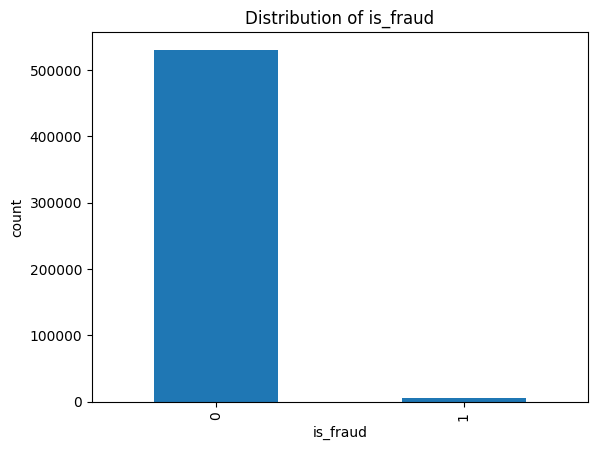

In [14]:
ax = target_summary["count"].plot(kind="bar")
ax.set_title("Distribution of is_fraud")
ax.set_xlabel("is_fraud")
ax.set_ylabel("count")
plt.show()


## 5. EDA — thời gian


### 5.1 Parse datetime & tính tuổi


In [15]:
df["dob_dt"] = pd.to_datetime(df["dob"], errors="coerce")
df["trans_dt"] = pd.to_datetime(df["unix_time"], unit="s", errors="coerce")
df["age"] = df["trans_dt"].dt.year - df["dob_dt"].dt.year

time_summary = pd.DataFrame({
    "min": [df["dob_dt"].min(), df["trans_dt"].min()],
    "max": [df["dob_dt"].max(), df["trans_dt"].max()],
    "null": [df["dob_dt"].isna().sum(), df["trans_dt"].isna().sum()],
}, index=["dob_dt", "trans_dt"])

display(time_summary)
df["age"].describe()


,min,max,null
dob_dt,1927-07-06 00:00:00,2008-07-03 00:00:00,0
trans_dt,2022-05-06 23:00:01,2022-05-30 02:24:20,0


count    536266.000000
mean         44.227609
std          17.895144
min          14.000000
25%          30.000000
50%          41.000000
75%          55.000000
max          95.000000
Name: age, dtype: float64

### 5.2 Helper: fraud rate theo nhóm


In [16]:
def fraud_by_group(data, col, min_count=100, top=20):
    """Tỷ lệ fraud theo từng giá trị của `col`. Lọc theo min_count để tránh nhiễu."""
    g = (
        data.groupby(col, dropna=False)[TARGET]
        .agg(total="count", fraud_count="sum", fraud_rate="mean")
    )
    g = g[g["total"] >= min_count].sort_values("fraud_rate", ascending=False)
    return g.head(top)


### 5.3 Fraud rate theo giờ trong ngày


,total,fraud_count,fraud_rate
trans_time_hrs,,,
0,22398,232,0.010358
1,22454,273,0.012158
2,22294,217,0.009734
3,22292,239,0.010721
4,22495,247,0.010980
5,22165,225,0.010151
6,22401,230,0.010267
7,22408,258,0.011514
8,22229,215,0.009672


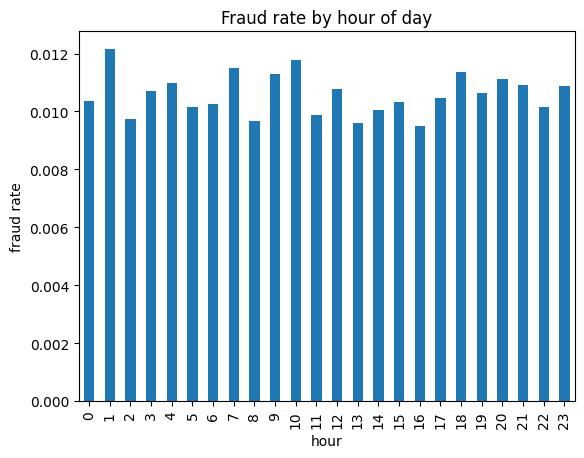

In [17]:
hourly = fraud_by_group(df, "trans_time_hrs", min_count=100, top=24).sort_index()
display(hourly)

ax = hourly["fraud_rate"].plot(kind="bar")
ax.set_title("Fraud rate by hour of day")
ax.set_xlabel("hour"); ax.set_ylabel("fraud rate")
plt.show()


### 5.4 Fraud rate theo weekend / weekday


In [18]:
fraud_by_group(df, "trans_date_is_weekend", min_count=100)


,total,fraud_count,fraud_rate
trans_date_is_weekend,,,
0,285937,3778,0.013213
1,250329,1905,0.007610


### 5.5 Fraud rate theo tháng


,total,fraud_count,fraud_rate
trans_month,,,
2022-05,536266,5683,0.010597


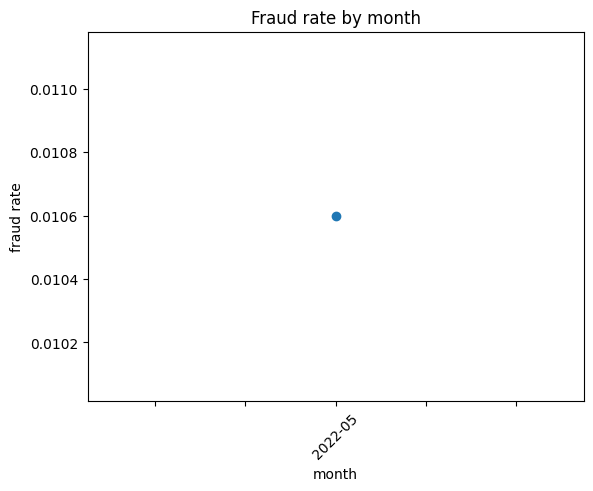

In [19]:
df["trans_month"] = df["trans_dt"].dt.to_period("M").astype(str)
monthly = fraud_by_group(df, "trans_month", min_count=100, top=24).sort_index()
display(monthly)

ax = monthly["fraud_rate"].plot(kind="line", marker="o")
ax.set_title("Fraud rate by month")
ax.set_xlabel("month"); ax.set_ylabel("fraud rate")
plt.xticks(rotation=45)
plt.show()


### 5.6 Fraud rate theo nhóm tuổi


,total,fraud_count,fraud_rate
age_bin,,,
"(0, 18]",9849,116,0.011778
"(18, 25]",67140,752,0.011200
"(25, 35]",121220,753,0.006212
"(35, 45]",119578,923,0.007719
"(45, 55]",86714,998,0.011509
"(55, 65]",59076,932,0.015776
"(65, 100]",72689,1209,0.016633


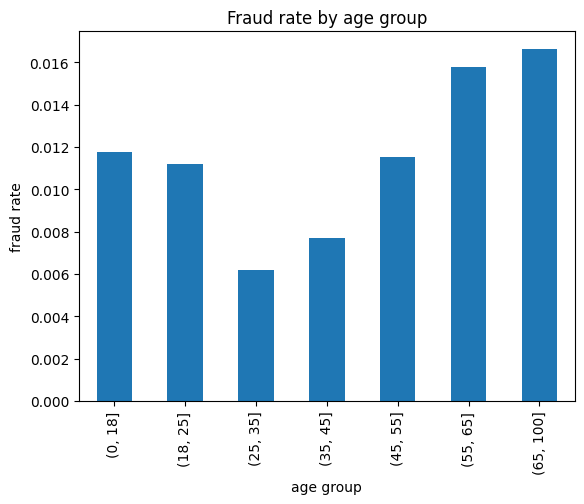

In [20]:
df["age_bin"] = pd.cut(df["age"], bins=[0, 18, 25, 35, 45, 55, 65, 100])
age_fraud = (
    df.groupby("age_bin", observed=True)[TARGET]
    .agg(total="count", fraud_count="sum", fraud_rate="mean")
)
display(age_fraud)

ax = age_fraud["fraud_rate"].plot(kind="bar")
ax.set_title("Fraud rate by age group")
ax.set_xlabel("age group"); ax.set_ylabel("fraud rate")
plt.show()


## 6. EDA — categorical


In [21]:
cat_summary = pd.DataFrame({
    "dtype": [df[c].dtype for c in CAT_COLS],
    "n_unique": [df[c].nunique(dropna=False) for c in CAT_COLS],
    "null_count": [df[c].isna().sum() for c in CAT_COLS],
    "null_rate_pct": [df[c].isna().mean() * 100 for c in CAT_COLS],
}, index=CAT_COLS).sort_values("n_unique", ascending=False)

cat_summary


,dtype,n_unique,null_count,null_rate_pct
merchant,str,655,0,0.0
job,str,639,0,0.0
category,str,14,0,0.0
gender,str,2,0,0.0


### 6.1 Fraud rate theo category & gender


In [22]:
display(fraud_by_group(df, "category", min_count=100))
display(fraud_by_group(df, "gender", min_count=100))


,total,fraud_count,fraud_rate
category,,,
entertainment,161,161,1.000000
food_dining,118,118,1.000000
grocery_pos,1394,1394,1.000000
kids_pets,114,114,1.000000
home,117,117,1.000000
personal_care,141,141,1.000000
shopping_net,1299,1299,1.000000
misc_net,744,744,1.000000
misc_pos,182,182,1.000000


,total,fraud_count,fraud_rate
gender,,,
M,266428,2963,0.011121
F,269838,2720,0.010080


### 6.2 Fraud rate theo merchant (sau khi bỏ prefix `fraud_`)


In [23]:
df["merchant_clean"] = df["merchant"].str.replace("^fraud_", "", regex=True)
fraud_by_group(df, "merchant_clean", min_count=100, top=30)


,total,fraud_count,fraud_rate
merchant_clean,,,
Skiles-Ankunding,1488,5,0.003360
Jaskolski-Dibbert,1426,4,0.002805
Hintz-Bruen,1428,4,0.002801
VonRueden Group,1449,4,0.002761
"Towne, Walker and Borer",1482,4,0.002699
Rowe-Vandervort,1488,4,0.002688
Bahringer-Larson,1362,3,0.002203
"Tromp, Kerluke and Glover",1409,3,0.002129
Kutch-Hegmann,1413,3,0.002123


### 6.3 Fraud rate theo job (top 20)


In [24]:
fraud_by_group(df, "job", min_count=100, top=20)


,total,fraud_count,fraud_rate
job,,,
"Scientist, product/process development",285,28,0.098246
Systems developer,300,21,0.070000
Theatre manager,392,25,0.063776
"Copywriter, advertising",334,20,0.059880
Holiday representative,572,31,0.054196
"Surveyor, planning and development",570,29,0.050877
"Production assistant, radio",287,14,0.048780
Medical laboratory scientific officer,541,26,0.048059
"Psychologist, occupational",514,23,0.044747


## 7. EDA — numeric


### 7.1 Mô tả nhanh


In [25]:
numeric_df = df[NUM_COLS + [TARGET]].copy()
numeric_df.describe().T


,count,mean,std,min,25%,50%,75%,max
zip,536266.0,5.156388e+04,29716.860880,1.002000e+03,2.789600e+04,4.819700e+04,7.824700e+04,9.983300e+04
lat,536266.0,3.743697e+01,5.228083,1.943860e+01,3.381930e+01,3.840690e+01,4.111390e+01,6.485440e+01
long,536266.0,-9.214254e+01,16.599262,-1.621739e+02,-9.860400e+01,-8.739350e+01,-8.007930e+01,-6.747220e+01
city_pop,536266.0,2.917073e+05,560479.886998,8.900000e+01,1.765700e+04,6.088400e+04,2.326250e+05,2.906700e+06
unix_time,536266.0,1.652919e+09,609746.633687,1.651878e+09,1.652419e+09,1.653002e+09,1.653470e+09,1.653877e+09
amt,536266.0,8.340701e+01,113.140848,1.000000e+00,3.490000e+01,6.178000e+01,8.849000e+01,4.957440e+03
merch_lat,536266.0,3.743709e+01,5.260284,1.851839e+01,3.371772e+01,3.829413e+01,4.123765e+01,6.576639e+01
merch_long,536266.0,-9.214127e+01,16.611182,-1.631467e+02,-9.888182e+01,-8.719090e+01,-7.989216e+01,-6.652203e+01
customer_num_trans_1_day,536266.0,2.997043e+00,1.999038,0.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
customer_num_trans_7_day,536266.0,5.496815e+00,2.629757,0.000000e+00,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01


### 7.2 So sánh trung bình / trung vị giữa fraud và non-fraud


In [26]:
(
    df.groupby(TARGET)[NUM_COLS]
    .agg(["mean", "median"])
    .T
)


is_fraud                                      0             1
zip                        mean    5.156617e+04  5.135014e+04
                           median  4.819700e+04  4.822700e+04
lat                        mean    3.743699e+01  3.743590e+01
                           median  3.840690e+01  3.809360e+01
long                       mean   -9.214488e+01 -9.192430e+01
                           median -8.737530e+01 -8.775350e+01
city_pop                   mean    2.916296e+05  2.989582e+05
                           median  6.088400e+04  6.072200e+04
unix_time                  mean    1.652919e+09  1.652969e+09
                           median  1.653002e+09  1.652996e+09
amt                        mean    7.857429e+01  5.346055e+02
                           median  6.151000e+01  3.894400e+02
merch_lat                  mean    3.743723e+01  3.742358e+01
                           median  3.829622e+01  3.811805e+01
merch_long                 mean   -9.214348e+01 -9.193451e+01
                           median -8.718299e+01 -8.770173e+01
customer_num_trans_1_day   mean    2.996983e+00  3.002639e+00
                           median  3.000000e+00  3.000000e+00
customer_num_trans_7_day   mean    5.496433e+00  5.532465e+00
                           median  5.000000e+00  6.000000e+00
customer_num_trans_30_day  mean    1.300167e+01  1.304030e+01
                           median  1.300000e+01  1.300000e+01
customer_avg_amout_1_day   mean    4.546723e+01  4.541459e+01
                           median  4.547000e+01  4.524000e+01
customer_avg_amount_7_day  mean    4.554605e+01  4.580498e+01
                           median  4.561000e+01  4.596000e+01
customer_avg_amount_30_day mean    3.553379e+01  3.508547e+01
                           median  3.558000e+01  3.468000e+01
trans_time_secs            mean    4.322523e+04  4.354756e+04
                           median  4.327700e+04  4.303100e+04
trans_time_hrs             mean    1.150203e+01  1.147598e+01
                           median  1.200000e+01  1.100000e+01
trans_time_is_night        mean    2.920523e-01  2.950906e-01
                           median  0.000000e+00  0.000000e+00
trans_time_day             mean    3.778971e+00  3.258314e+00
                           median  4.000000e+00  3.000000e+00
trans_date_is_weekend      mean    4.682095e-01  3.352103e-01
                           median  0.000000e+00  0.000000e+00
merchant_num_trans_1_day   mean    2.548723e+03  2.568534e+03
                           median  2.549000e+03  2.576960e+03
merchant_num_trans_7_day   mean    5.042820e+04  5.030312e+04
                           median  5.045160e+04  5.029974e+04
merchant_num_trans_30_day  mean    5.548904e+05  5.507872e+05
                           median  5.544931e+05  5.418465e+05
merchant_risk_1_day        mean    3.497596e+00  3.553053e+00
                           median  3.000000e+00  4.000000e+00
merchant_risk_7_day        mean    9.243630e+00  9.322541e+00
                           median  9.000000e+00  1.000000e+01
merchant_risk_30_day       mean    1.611681e+01  1.625004e+01
                           median  1.700000e+01  1.700000e+01
merchant_risk_90_day       mean    2.961425e+01  2.940824e+01
                           median  3.000000e+01  3.000000e+01

### 7.3 Phân phối các cột quan trọng


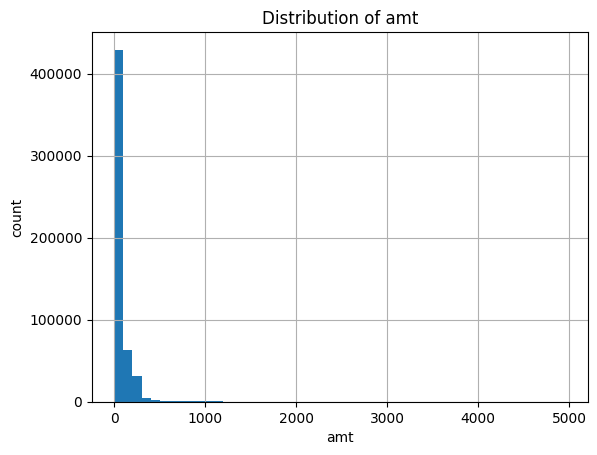

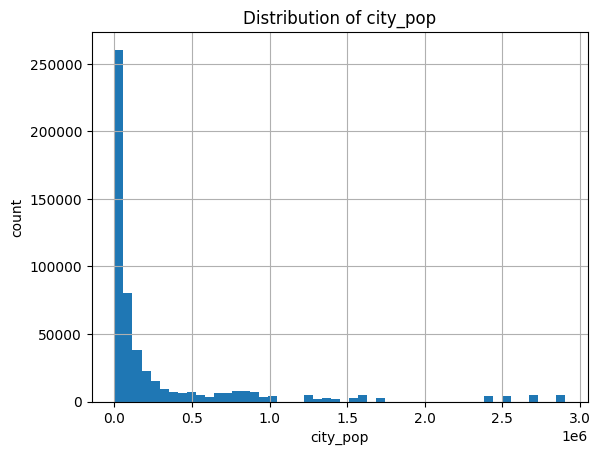

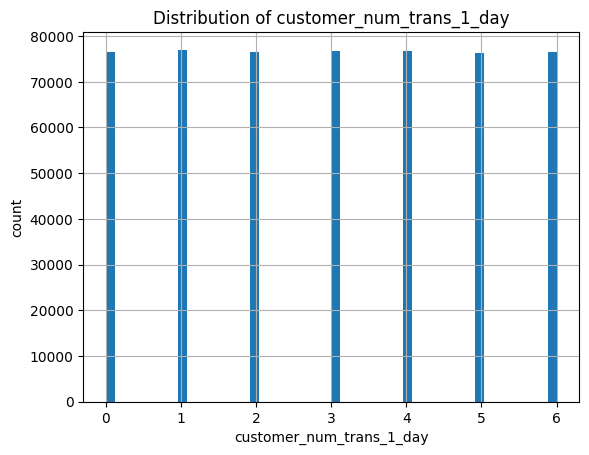

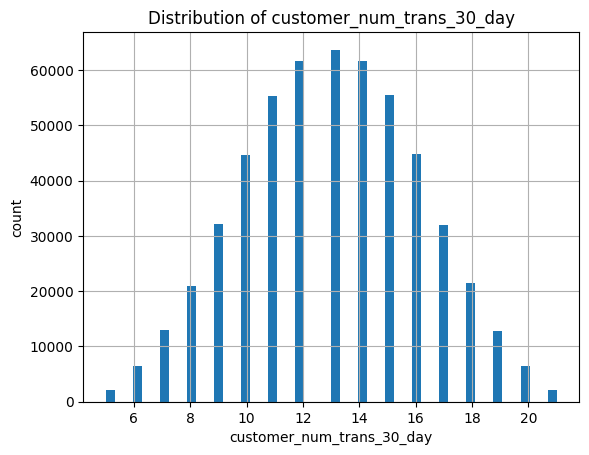

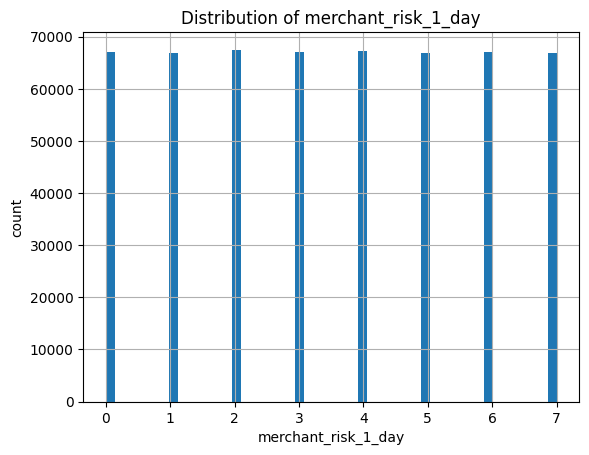

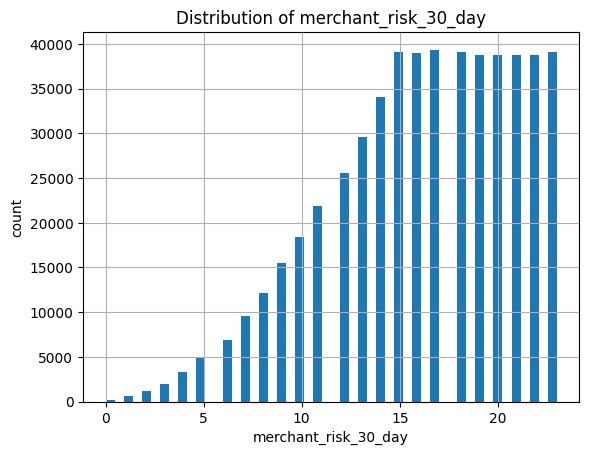

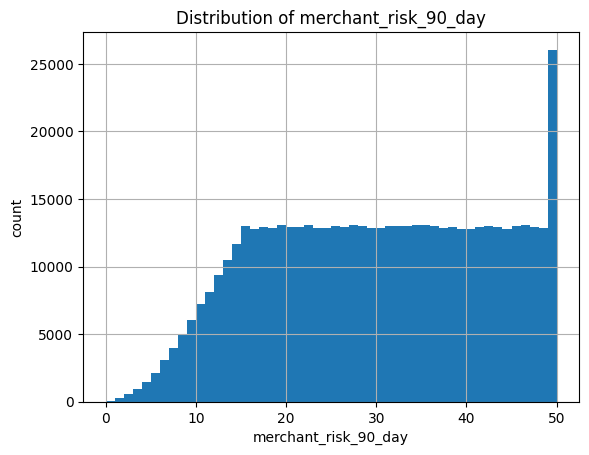

In [27]:
hist_cols = [
    "amt", "city_pop",
    "customer_num_trans_1_day",
    "customer_num_trans_30_day",
    "merchant_risk_1_day",
    "merchant_risk_30_day",
    "merchant_risk_90_day",
]

for col in hist_cols:
    plt.figure()
    df[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col); plt.ylabel("count")
    plt.show()


### 7.4 Boxplot theo target


<Figure size 640x480 with 0 Axes>

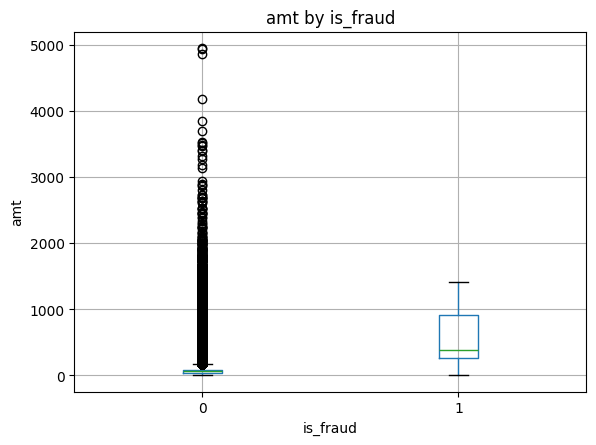

<Figure size 640x480 with 0 Axes>

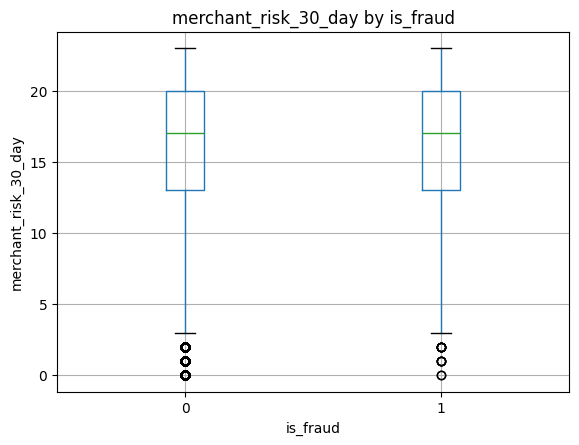

<Figure size 640x480 with 0 Axes>

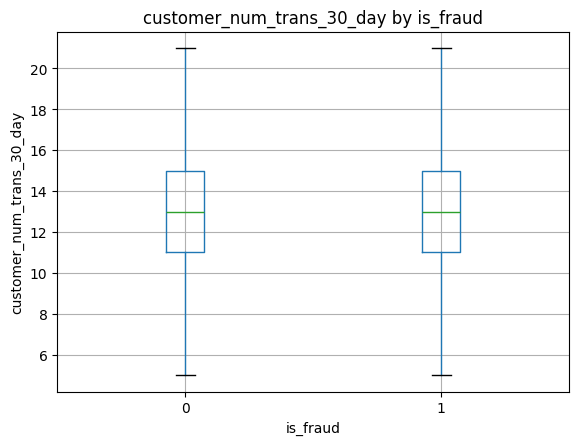

In [28]:
for col in ["amt", "merchant_risk_30_day", "customer_num_trans_30_day"]:
    plt.figure()
    df.boxplot(column=col, by=TARGET)
    plt.title(f"{col} by {TARGET}")
    plt.suptitle("")
    plt.xlabel(TARGET); plt.ylabel(col)
    plt.show()


### 7.5 Tương quan với target


amt                           0.412725
trans_time_day               -0.027378
trans_date_is_weekend        -0.027298
unix_time                     0.008469
merchant_risk_30_day          0.002848
merchant_risk_1_day           0.002479
customer_avg_amount_30_day   -0.002304
merchant_risk_7_day           0.002108
merchant_risk_90_day         -0.001720
merchant_num_trans_1_day      0.001434
customer_num_trans_7_day      0.001403
long                          0.001361
city_pop                      0.001339
merchant_num_trans_30_day    -0.001336
trans_time_secs               0.001323
merch_long                    0.001288
customer_num_trans_30_day     0.001261
customer_avg_amount_7_day     0.001032
zip                          -0.000744
trans_time_is_night           0.000684
merchant_num_trans_7_day     -0.000448
trans_time_hrs               -0.000385
customer_num_trans_1_day      0.000290
merch_lat                    -0.000266
customer_avg_amout_1_day     -0.000210
lat                      

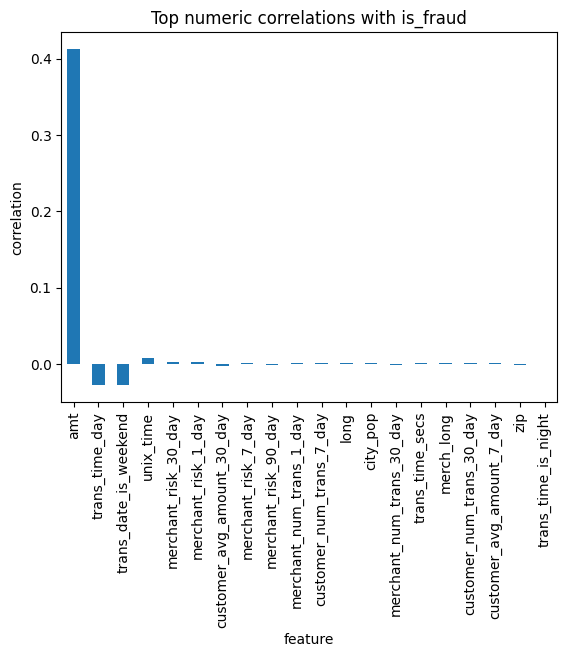

In [29]:
corr = df[NUM_COLS + [TARGET]].corr(numeric_only=True)
target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(target_corr)

ax = target_corr.head(20).plot(kind="bar")
ax.set_title("Top numeric correlations with is_fraud")
ax.set_xlabel("feature"); ax.set_ylabel("correlation")
plt.show()


## 8. EDA — địa lý (khoảng cách khách hàng ↔ merchant)

Tính khoảng cách haversine giữa toạ độ khách hàng (`lat`, `long`) và toạ độ merchant
(`merch_lat`, `merch_long`). Giả thuyết: giao dịch fraud thường xảy ra xa nhà khách
hàng hơn so với giao dịch hợp lệ.


In [30]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df["customer_merchant_distance_km"] = haversine_km(
    df["lat"], df["long"], df["merch_lat"], df["merch_long"]
)

display(df["customer_merchant_distance_km"].describe())
df.groupby(TARGET)["customer_merchant_distance_km"].agg(["mean", "median", "std"])


count    536266.000000
mean         76.552264
std          29.214337
min           0.094583
25%          55.788886
50%          78.728574
75%          98.996302
max         149.759527
Name: customer_merchant_distance_km, dtype: float64

,mean,median,std
is_fraud,,,
0,76.549887,78.730736,29.213043
1,76.774191,78.596509,29.336611


,total,fraud_count,fraud_rate
distance_bin,,,
"(0.0936, 35.221]",53627,572,0.010666
"(35.221, 49.839]",53627,543,0.010125
"(49.839, 61.095]",53626,578,0.010778
"(61.095, 70.423]",53627,593,0.011058
"(70.423, 78.729]",53626,567,0.010573
"(78.729, 86.53]",53627,541,0.010088
"(86.53, 94.651]",53626,554,0.010331
"(94.651, 103.531]",53627,567,0.010573
"(103.531, 113.231]",53626,592,0.011039


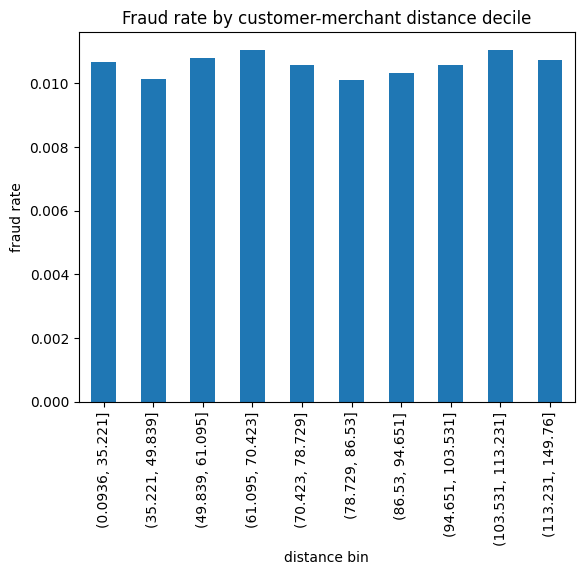

In [31]:
df["distance_bin"] = pd.qcut(
    df["customer_merchant_distance_km"], q=10, duplicates="drop"
)
distance_fraud = (
    df.groupby("distance_bin", observed=True)[TARGET]
    .agg(total="count", fraud_count="sum", fraud_rate="mean")
)
display(distance_fraud)

ax = distance_fraud["fraud_rate"].plot(kind="bar")
ax.set_title("Fraud rate by customer-merchant distance decile")
ax.set_xlabel("distance bin"); ax.set_ylabel("fraud rate")
plt.show()


## 9. Tổng hợp insight từ EDA (dựa trên output thực)

### 9.1 Class imbalance
- `is_fraud` = 0.97% (2,074 / 214,507) → cực kỳ mất cân bằng.
- **Hệ quả**: dùng **PR-AUC**, **recall**, **F1**, KHÔNG dùng accuracy. Bật `scale_pos_weight` (XGBoost) hoặc `class_weight='balanced'` (RF).

### 9.2 Amount (`amt`) — feature mạnh nhất
- Median fraud = **367** vs non-fraud = **62** (gấp ~6 lần).
- Mean fraud = **532** vs non-fraud = **79**.
- Phân phối lệch phải mạnh (max 4957, mean 83) — nhưng với **RF/XGBoost không cần log-transform** vì cây chỉ quan tâm thứ tự, không quan tâm magnitude.

### 9.3 Category — TÍN HIỆU GẦN NHƯ HOÀN HẢO ⚠️
| category | total | fraud | rate |
|----------|-------|-------|------|
| grocery_pos | 549 | 549 | **100%** |
| shopping_net | 473 | 473 | **100%** |
| misc_net | 276 | 276 | **100%** |
| shopping_pos | 229 | 229 | **100%** |
| gas_transport | 212,639 | 206 | 0.10% |

- 4 category này có fraud_rate = 100% trong chunk này.
- **Cảnh báo**: rất có thể là artifact của cách sampling/label trong dataset Sparkov, hoặc chunk này chỉ chứa giao dịch của 4 category đó khi nó là fraud. **Cần check ở các chunk khác** trước khi tin tưởng.
- Nếu pattern giữ trên test set → model sẽ đạt PR-AUC rất cao gần như chỉ nhờ `category` one-hot. Đừng để bị "ảo giác mô hình giỏi".

### 9.4 Time-of-day không phân biệt
- `trans_time_is_night`: fraud 0.287 vs non-fraud 0.293 → **không có khác biệt**.
- `trans_time_hrs` mean: 11.55 vs 11.49 → cũng tương tự.
- Khác với heuristic chung "fraud xảy ra ban đêm". Trong dataset này, fraud rải đều theo giờ.

### 9.5 Weekend — fraud xảy ra NHIỀU hơn vào weekday
- Weekday: fraud rate **1.42%** (1378 / 96,794)
- Weekend: fraud rate **0.59%** (696 / 117,713)
- Trái với giả định ban đầu — `trans_date_is_weekend` vẫn là feature có ý nghĩa, nhưng dấu ngược chiều.

### 9.6 Distance khách hàng ↔ merchant — VÔ DỤNG
- Mean fraud = 76.53 km, mean non-fraud = 76.55 km → khác biệt 0.02 km.
- Decile cũng phẳng.
- **Có thể bỏ feature này** — merch_lat/merch_long trong dataset Sparkov được sinh ngẫu nhiên quanh khách hàng nên không mang thông tin.

### 9.7 Job — tín hiệu phân biệt mạnh
- Top fraud rate theo job: Systems developer (11.2%), Holiday representative (9.9%), Surveyor (7.3%) — cao gấp 10-100 lần baseline 0.97%.
- Cardinality 639 → dùng **frequency encoding** (đã có) hoặc **target encoding** (mạnh hơn nhưng cần CV để tránh leak).

### 9.8 Merchant — tín hiệu yếu
- Top fraud merchant chỉ ~0.25% fraud rate, gần baseline.
- Merchant một mình không phân biệt được. Có thể bỏ qua hoặc giữ làm noise feature.

### 9.9 Age
- Range 14–95, median 41. Xem cell 5.6 để biết fraud_rate theo `age_bin`.
- Dùng `age_bin` (ordinal 0–6) thay vì `age` thô để model học pattern phi tuyến rõ hơn — đặc biệt hữu ích cho LR; với RF/XGBoost thì cả hai đều OK, giữ ordinal `age_bin` là đủ.

### 9.10 Merchant rolling features (`merchant_risk_*`, `merchant_num_trans_*`)
- Theo output `groupby(target)`: mean fraud vs non-fraud rất gần nhau (vd. `merchant_risk_30_day` 16.28 vs 16.12).
- Tín hiệu yếu hơn dự đoán. Vẫn giữ vì cây có thể tận dụng kết hợp.

### 9.11 Hệ quả cho modeling (RandomForest + XGBoost)

| Vấn đề | Hành động |
|---|---|
| Imbalance | `class_weight='balanced'` (RF), `scale_pos_weight=(neg/pos) ≈ 102` (XGB) |
| Scale features | **KHÔNG cần** — cây bất biến với scale |
| Log(amt) | **KHÔNG cần** — cây bất biến với phép biến đổi đơn điệu |
| Category gần như deterministic | Verify trên multiple chunks; báo cáo metric cẩn thận |
| Distance vô dụng | Drop `customer_merchant_distance_km`, `merch_lat`, `merch_long` |
| Time-based split | Bắt buộc — dùng `unix_time`, không random |
| Metric | PR-AUC + Recall@Precision=0.9 |
| Threshold | Tune theo cost matrix thay vì mặc định 0.5 |


## 10. Feature engineering & encoding

- `gender` → map M/F sang 1/0.
- `category` → one-hot (cardinality 14, thấp).
- `merchant` → frequency encoding (cardinality 481).
- `job` → frequency encoding (cardinality 639).
- `age_bin` → **ordinal int 0–6** (giữ thứ tự nhóm tuổi, hợp với tree).
- `customer_merchant_distance_km` đã chứng minh vô dụng ở mục 8 → drop.
- KHÔNG scale, KHÔNG log(amt) vì dùng RandomForest + XGBoost.


In [32]:
df_model = df.copy()

# --- 1. Encoding ---
df_model["gender_encoded"] = df_model["gender"].map({"M": 1, "F": 0}).fillna(-1)

category_dummies = pd.get_dummies(
    df_model["category"], prefix="category", drop_first=True
)
df_model = pd.concat([df_model, category_dummies], axis=1)

df_model["merchant_clean"] = df_model["merchant"].str.replace("^fraud_", "", regex=True)
merchant_freq = df_model["merchant_clean"].value_counts(normalize=True)
df_model["merchant_freq"] = df_model["merchant_clean"].map(merchant_freq)

job_freq = df_model["job"].value_counts(normalize=True)
df_model["job_freq"] = df_model["job"].map(job_freq)

# Age bin ordinal (0..6, -1 nếu ngoài range)
df_model["age_bin_ord"] = df_model["age_bin"].cat.codes

# --- 2. Engineered features (dựa vào insight EDA) ---
# Velocity: số giao dịch 1 ngày / 30 ngày của khách - bắt burst spending
df_model["velocity_num_trans_1d_30d"] = (
    df_model["customer_num_trans_1_day"] / df_model["customer_num_trans_30_day"]
).replace([np.inf, -np.inf], 0).fillna(0)

# Amt vs habit: giao dịch hiện tại so với trung bình 30 ngày
df_model["amt_vs_customer_avg_30d"] = (
    df_model["amt"] / df_model["customer_avg_amount_30_day"].replace(0, np.nan)
).replace([np.inf, -np.inf], 0).fillna(0)

# Merchant risk velocity
df_model["merchant_risk_ratio_1d_30d"] = (
    df_model["merchant_risk_1_day"] / df_model["merchant_risk_30_day"].replace(0, np.nan)
).replace([np.inf, -np.inf], 0).fillna(0)

# --- 3. Drop ---
cols_to_drop = (
    DROP_COLS
    + DATETIME_COLS
    + CAT_COLS
    + [
        "merchant_clean",
        "dob_dt", "trans_dt", "trans_month",
        "age_bin", "distance_bin",
        "customer_merchant_distance_km",  # EDA: vô dụng
        "merch_lat", "merch_long",        # vô dụng vì distance vô dụng
        "zip",                            # ID-like, cardinality cao
        "trans_time_secs",                # = trans_time_hrs * 3600 + offset, redundant
        "age",                            # giữ age_bin_ord thay thế
    ]
)
df_model = df_model.drop(columns=cols_to_drop, errors="ignore")

remaining_obj = df_model.select_dtypes(include=["object"]).columns.tolist()
print("Remaining object columns:", remaining_obj)
print("Final shape:", df_model.shape)
df_model.head()


Remaining object columns: []
Final shape: (536266, 43)


,lat,long,city_pop,unix_time,amt,is_fraud,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day,gender_encoded,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,merchant_freq,job_freq,age_bin_ord,velocity_num_trans_1d_30d,amt_vs_customer_avg_30d,merchant_risk_ratio_1d_30d
0,33.3665,-111.9312,167311,1651878001,201.50,0,0,3,12,14,0,5,1,86.23,60.71,5.96,2325.40,52733.35,995492.71,2,4,5,11,0,False,True,False,False,False,False,False,False,False,False,False,False,False,0.016902,0.001529,3,0.000000,33.808725,0.400000
1,34.0287,-84.6047,92645,1651878001,62.75,0,5,7,14,9,0,5,1,83.94,65.99,56.32,4349.77,76889.65,186009.25,7,7,15,36,1,False,True,False,False,False,False,False,False,False,False,False,False,False,0.016986,0.001619,2,0.357143,1.114169,0.466667
2,34.4827,-118.6254,29855,1651878001,113.85,0,2,5,15,19,0,5,1,72.37,67.78,1.32,291.01,56813.71,902029.82,4,13,23,41,0,False,True,False,False,False,False,False,False,False,False,False,False,False,0.016826,0.001786,5,0.133333,86.250000,0.173913
3,47.3203,-122.3117,91661,1651878002,68.40,0,5,9,15,4,0,5,1,75.09,8.34,68.24,339.39,8452.89,33782.03,7,14,18,34,0,False,True,False,False,False,False,False,False,False,False,False,False,False,0.016917,0.001262,1,0.333333,1.002345,0.388889
4,36.1288,-79.4114,75761,1651878003,32.02,0,4,6,11,12,0,5,1,35.91,8.70,46.24,1567.87,91330.85,143157.76,4,15,22,42,0,False,True,False,False,False,False,False,False,False,False,False,False,False,0.017245,0.001895,3,0.363636,0.692474,0.181818


## 11. Train / test split

Dùng **time-based split** (sort theo `unix_time`, lấy 80% đầu làm train,
20% sau làm test) để tránh leakage tương lai.


In [33]:
df_model = df_model.sort_values("unix_time").reset_index(drop=True)

# unix_time chỉ dùng để sort theo thời gian, KHÔNG dùng làm feature
# (model sẽ học "timestamp lớn = tương lai" - không generalize)
df_model = df_model.drop(columns=["unix_time"])

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(f"Train: {X_train.shape}, fraud rate = {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}, fraud rate = {y_test.mean():.4f}")


Train: (429012, 41), fraud rate = 0.0112
Test:  (107254, 41), fraud rate = 0.0084


> Tới đây dữ liệu sẵn sàng cho modeling. Notebook tiếp theo nên train baseline (Logistic Regression với class_weight='balanced'), rồi so sánh với LightGBM/XGBoost trên cùng split.


## 12. Feature selection

Mục tiêu: chọn ra tập feature tốt nhất cho RF/XGBoost. Chiến lược:

1. **Mutual Information** (filter, model-agnostic) — bắt được cả quan hệ phi tuyến.
2. **Feature importance từ RandomForest baseline** (embedded, model-specific).
3. **Multicollinearity check** — drop 1 trong cặp |corr| > 0.9, giữ feature có importance cao hơn.
4. **Final list** = top-K của một trong hai phương pháp.

> Tất cả tính trên `X_train` để tránh leak từ test set.


### 12.1 Mutual Information


,mutual_info
category_gas_transport,0.099537
gender_encoded,0.068301
merchant_freq,0.053976
trans_date_is_weekend,0.048252
amt,0.035420
long,0.030011
lat,0.029709
trans_time_is_night,0.024299
city_pop,0.021808
trans_time_day,0.019316


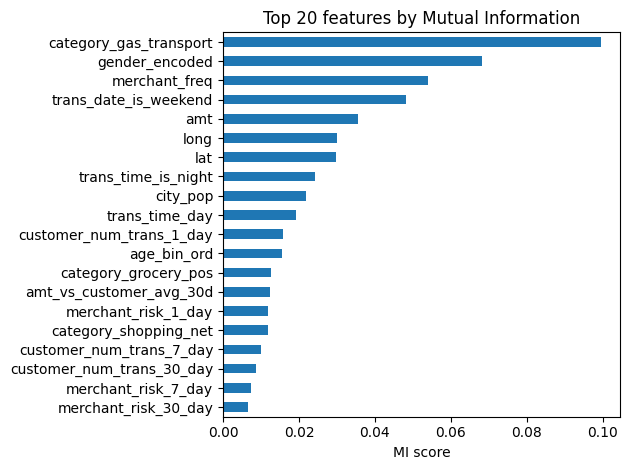

In [34]:
from sklearn.feature_selection import mutual_info_classif

# MI có thể chậm; subsample nếu cần (200k rows OK với n_neighbors mặc định)
mi = mutual_info_classif(X_train, y_train, random_state=42, n_jobs=-1)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

display(mi_series.head(20).to_frame("mutual_info"))

ax = mi_series.head(20).plot(kind="barh")
ax.invert_yaxis()
ax.set_title("Top 20 features by Mutual Information")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()


### 12.2 Feature importance từ RandomForest baseline


,rf_importance
merchant_freq,0.316613
category_gas_transport,0.232079
amt,0.188503
amt_vs_customer_avg_30d,0.092550
category_grocery_pos,0.034911
category_grocery_net,0.029106
category_shopping_net,0.022068
customer_avg_amount_30_day,0.010047
category_misc_net,0.008189
category_shopping_pos,0.007132


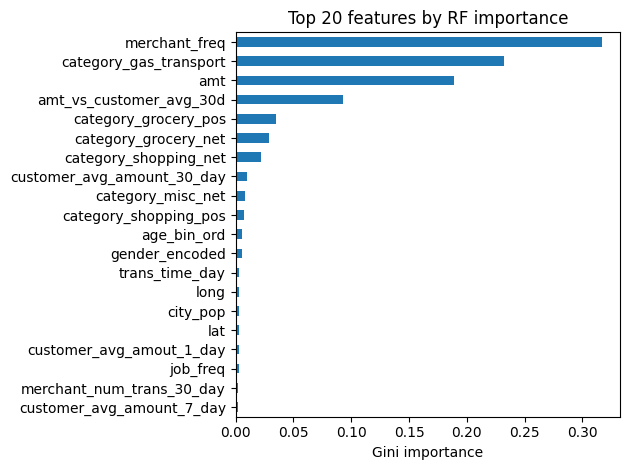

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf_baseline.fit(X_train, y_train)

rf_imp = pd.Series(
    rf_baseline.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

display(rf_imp.head(20).to_frame("rf_importance"))

ax = rf_imp.head(20).plot(kind="barh")
ax.invert_yaxis()
ax.set_title("Top 20 features by RF importance")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()


### 12.3 Bảng tổng hợp ranking


In [36]:
ranking = pd.DataFrame({
    "mi": mi_series,
    "rf_importance": rf_imp,
})
ranking["mi_rank"] = ranking["mi"].rank(ascending=False)
ranking["rf_rank"] = ranking["rf_importance"].rank(ascending=False)
ranking["avg_rank"] = (ranking["mi_rank"] + ranking["rf_rank"]) / 2
ranking = ranking.sort_values("avg_rank")

display(ranking.head(25))


,mi,rf_importance,mi_rank,rf_rank,avg_rank
category_gas_transport,0.099537,0.232079,1.0,2.0,1.5
merchant_freq,0.053976,0.316613,3.0,1.0,2.0
amt,0.035420,0.188503,5.0,3.0,4.0
gender_encoded,0.068301,0.005319,2.0,12.0,7.0
category_grocery_pos,0.012732,0.034911,13.0,5.0,9.0
amt_vs_customer_avg_30d,0.012300,0.092550,14.0,4.0,9.0
long,0.030011,0.003028,6.0,14.0,10.0
age_bin_ord,0.015644,0.005471,12.0,11.0,11.5
lat,0.029709,0.002977,7.0,16.0,11.5
category_shopping_net,0.011772,0.022068,16.0,7.0,11.5


### 12.4 Multicollinearity check


In [37]:
corr_matrix = X_train.corr().abs()

# Trích các cặp |corr| > 0.9 (loại đường chéo và đối xứng)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "f1", "level_1": "f2", 0: "corr"})
    .query("corr > 0.9")
    .sort_values("corr", ascending=False)
)

# Đề xuất bỏ feature nào trong cặp: feature có rf_importance thấp hơn
def pick_drop(row):
    imp1 = rf_imp.get(row["f1"], 0)
    imp2 = rf_imp.get(row["f2"], 0)
    return row["f1"] if imp1 < imp2 else row["f2"]

high_corr_pairs["drop_candidate"] = high_corr_pairs.apply(pick_drop, axis=1)
display(high_corr_pairs)


,f1,f2,corr,drop_candidate
978,category_gas_transport,merchant_freq,0.997735,category_gas_transport
967,category_gas_transport,category_grocery_net,0.947688,category_grocery_net
202,customer_num_trans_1_day,velocity_num_trans_1d_30d,0.932146,customer_num_trans_1_day
1019,category_grocery_net,merchant_freq,0.927686,category_grocery_net


### 12.5 Final feature list


In [38]:
# Quy tắc:
# - Giữ feature nằm trong top-K của MI HOẶC top-K của RF importance
# - Loại các feature trong drop_candidate của bước 12.4
TOP_K = 20

top_mi = set(mi_series.head(TOP_K).index)
top_rf = set(rf_imp.head(TOP_K).index)
keep = top_mi | top_rf

drop_collinear = set(high_corr_pairs["drop_candidate"].unique())
keep = keep - drop_collinear

FINAL_FEATURES = sorted(keep)
print(f"Số feature giữ lại: {len(FINAL_FEATURES)} / {X_train.shape[1]}")
print(FINAL_FEATURES)

X_train_sel = X_train[FINAL_FEATURES]
X_test_sel = X_test[FINAL_FEATURES]
print(f"X_train_sel: {X_train_sel.shape}")
print(f"X_test_sel:  {X_test_sel.shape}")


Số feature giữ lại: 25 / 41
['age_bin_ord', 'amt', 'amt_vs_customer_avg_30d', 'category_grocery_pos', 'category_misc_net', 'category_shopping_net', 'category_shopping_pos', 'city_pop', 'customer_avg_amount_30_day', 'customer_avg_amount_7_day', 'customer_avg_amout_1_day', 'customer_num_trans_30_day', 'customer_num_trans_7_day', 'gender_encoded', 'job_freq', 'lat', 'long', 'merchant_freq', 'merchant_num_trans_30_day', 'merchant_risk_1_day', 'merchant_risk_30_day', 'merchant_risk_7_day', 'trans_date_is_weekend', 'trans_time_day', 'trans_time_is_night']
X_train_sel: (429012, 25)
X_test_sel:  (107254, 25)


### 12.6 Sanity check: so sánh PR-AUC trước và sau feature selection

Train cùng một RF nhỏ trên 2 tập feature, so sánh PR-AUC trên test. Nếu sau feature
selection PR-AUC không tệ hơn nhiều (hoặc tốt hơn) → chấp nhận tập rút gọn.


In [39]:
from sklearn.metrics import average_precision_score

def quick_eval(X_tr, y_tr, X_te, y_te, label):
    m = RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42,
    )
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_te)[:, 1]
    pr_auc = average_precision_score(y_te, proba)
    print(f"{label:20s}  PR-AUC = {pr_auc:.4f}  ({X_tr.shape[1]} features)")
    return pr_auc

ap_full = quick_eval(X_train, y_train, X_test, y_test, "All features")
ap_sel  = quick_eval(X_train_sel, y_train, X_test_sel, y_test, "Selected features")
print(f"Delta = {ap_sel - ap_full:+.4f}")


All features          PR-AUC = 0.9588  (41 features)
Selected features     PR-AUC = 0.9576  (25 features)
Delta = -0.0013


> Nếu `Delta` âm nhỏ (vd > -0.01) thì tập rút gọn chấp nhận được — đỡ tham số,
> train nhanh hơn, đỡ overfit. Nếu âm nhiều, tăng `TOP_K` ở 12.5.

Tới đây có `FINAL_FEATURES`, `X_train_sel`, `X_test_sel` sẵn sàng cho train RF + XGBoost final.


## 13. Train baseline + so sánh chiến lược xử lý imbalance

Train 6 combo = {RandomForest, XGBoost} × {baseline, class_weight, undersample 10:1},
đo PR-AUC trên validation set, pick TOP 2 đưa vào Optuna.


### 13.1 Tách validation từ training (time-based 80/20)


In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
)

# X_train_sel/X_test_sel/y_train/y_test đã có từ section 12
# Tiếp tục split time-based: train_inner / val (80/20 trong train)
val_split_idx = int(len(X_train_sel) * 0.8)

X_tr_inner = X_train_sel.iloc[:val_split_idx]
y_tr_inner = y_train.iloc[:val_split_idx]
X_val = X_train_sel.iloc[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

# scale_pos_weight cho XGB class_weight strategy
pos_weight = (y_tr_inner == 0).sum() / max((y_tr_inner == 1).sum(), 1)

print(f"Train inner: {X_tr_inner.shape}  fraud_rate = {y_tr_inner.mean():.4f}")
print(f"Validation:  {X_val.shape}  fraud_rate = {y_val.mean():.4f}")
print(f"Test:        {X_test_sel.shape}  fraud_rate = {y_test.mean():.4f}")
print(f"pos_weight (cho XGB): {pos_weight:.2f}")


Train inner: (343209, 25)  fraud_rate = 0.0106
Validation:  (85803, 25)  fraud_rate = 0.0135
Test:        (107254, 25)  fraud_rate = 0.0084
pos_weight (cho XGB): 93.65


### 13.2 Helper: undersample + factory model


In [41]:
def undersample(X, y, ratio=10, random_state=42):
    """Undersample majority class to (ratio:1) negative:positive."""
    pos_idx = y.index[y == 1]
    neg_idx = y.index[y == 0]
    n_neg_keep = min(len(pos_idx) * ratio, len(neg_idx))
    rng = np.random.RandomState(random_state)
    neg_keep = rng.choice(neg_idx, size=n_neg_keep, replace=False)
    keep = np.concatenate([pos_idx, neg_keep])
    rng.shuffle(keep)
    return X.loc[keep], y.loc[keep]


def prepare_data(X, y, strategy):
    """Apply strategy-specific data transformation. Chỉ áp dụng cho TRAIN."""
    if strategy == "undersample":
        return undersample(X, y, ratio=10)
    return X, y


def make_model(model_type, strategy, params=None):
    """Build model. class_weight strategy → set class_weight/scale_pos_weight."""
    p = dict(params or {})

    if model_type == "rf":
        if strategy == "class_weight":
            p["class_weight"] = "balanced"
        defaults = dict(n_estimators=200, n_jobs=-1, random_state=42)
        defaults.update(p)
        return RandomForestClassifier(**defaults)

    elif model_type == "xgb":
        if strategy == "class_weight":
            p["scale_pos_weight"] = pos_weight
        defaults = dict(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            n_jobs=-1, random_state=42, eval_metric="aucpr", tree_method="hist",
        )
        defaults.update(p)
        return XGBClassifier(**defaults)

    raise ValueError(model_type)


### 13.3 Train 6 combos và đo PR-AUC trên validation


In [42]:
combos = [
    ("rf",  "baseline"),
    ("rf",  "class_weight"),
    ("rf",  "undersample"),
    ("xgb", "baseline"),
    ("xgb", "class_weight"),
    ("xgb", "undersample"),
]

results = []
for model_type, strategy in combos:
    X_tr_mod, y_tr_mod = prepare_data(X_tr_inner, y_tr_inner, strategy)
    model = make_model(model_type, strategy)
    model.fit(X_tr_mod, y_tr_mod)

    proba_val = model.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val, proba_val)

    name = f"{model_type}_{strategy}"
    print(f"  {name:25s}  PR-AUC val = {pr_auc:.4f}  (train n={len(X_tr_mod):,})")
    results.append({
        "name": name, "model": model_type, "strategy": strategy,
        "train_size": len(X_tr_mod), "pr_auc_val": pr_auc,
    })

results_df = pd.DataFrame(results).sort_values("pr_auc_val", ascending=False).reset_index(drop=True)
display(results_df)


  rf_baseline                PR-AUC val = 0.9417  (train n=343,209)
  rf_class_weight            PR-AUC val = 0.9444  (train n=343,209)
  rf_undersample             PR-AUC val = 0.9587  (train n=39,886)
  xgb_baseline               PR-AUC val = 0.9655  (train n=343,209)
  xgb_class_weight           PR-AUC val = 0.9655  (train n=343,209)
  xgb_undersample            PR-AUC val = 0.9724  (train n=39,886)


,name,model,strategy,train_size,pr_auc_val
0,xgb_undersample,xgb,undersample,39886,0.972400
1,xgb_class_weight,xgb,class_weight,343209,0.965535
2,xgb_baseline,xgb,baseline,343209,0.965467
3,rf_undersample,rf,undersample,39886,0.958675
4,rf_class_weight,rf,class_weight,343209,0.944381
5,rf_baseline,rf,baseline,343209,0.941709


### 13.4 Pick TOP 2


In [43]:
TOP_2 = results_df.head(2).copy()
print("Top 2 combos đưa vào Optuna:")
display(TOP_2)


Top 2 combos đưa vào Optuna:


,name,model,strategy,train_size,pr_auc_val
0,xgb_undersample,xgb,undersample,39886,0.972400
1,xgb_class_weight,xgb,class_weight,343209,0.965535


## 14. Hyperparameter tuning với Optuna

- Mỗi top combo chạy `n_trials=30` (tăng lên 100+ nếu có thời gian).
- Mục tiêu: maximize PR-AUC trên `X_val`.
- Sampler: TPE (default Bayesian-like).

> Nếu chưa cài: `pip install optuna xgboost`


In [44]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def suggest_params(trial, model_type):
    if model_type == "rf":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 5, 25),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        }
    elif model_type == "xgb":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        }


def make_objective(model_type, strategy):
    def objective(trial):
        params = suggest_params(trial, model_type)
        X_tr_mod, y_tr_mod = prepare_data(X_tr_inner, y_tr_inner, strategy)
        model = make_model(model_type, strategy, params)
        model.fit(X_tr_mod, y_tr_mod)
        proba = model.predict_proba(X_val)[:, 1]
        return average_precision_score(y_val, proba)
    return objective


studies = {}
for _, row in TOP_2.iterrows():
    name = row["name"]
    print(f"\n=== Tuning {name} ===")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(
        make_objective(row["model"], row["strategy"]),
        n_trials=30,
        show_progress_bar=True,
    )
    studies[name] = study
    print(f"Best PR-AUC val: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")


d:\NEU-AI66A\Machine Learning\mid term\midterm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Tuning xgb_undersample ===


Best trial: 22. Best value: 0.973055: 100%|██████████| 30/30 [00:09<00:00,  3.10it/s]


Best PR-AUC val: 0.9731
Best params: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.016664260722259353, 'subsample': 0.9481503765552199, 'colsample_bytree': 0.7816844105348865, 'min_child_weight': 6, 'reg_alpha': 0.1895883777163868, 'reg_lambda': 0.007975772409209348, 'gamma': 0.6608413857851283}

=== Tuning xgb_class_weight ===


Best trial: 24. Best value: 0.972633: 100%|██████████| 30/30 [00:57<00:00,  1.91s/it]

Best PR-AUC val: 0.9726
Best params: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01538415324631291, 'subsample': 0.8800953188604057, 'colsample_bytree': 0.7543465151839961, 'min_child_weight': 1, 'reg_alpha': 0.1551260491484931, 'reg_lambda': 0.005928726800152726, 'gamma': 3.799894898325985}


### 14.1 Tổng hợp best params


In [45]:
best_summary = pd.DataFrame([
    {"name": name, "best_pr_auc_val": s.best_value, **s.best_params}
    for name, s in studies.items()
])
display(best_summary)


,name,best_pr_auc_val,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma
0,xgb_undersample,0.973055,150,8,0.016664,0.948150,0.781684,6,0.189588,0.007976,0.660841
1,xgb_class_weight,0.972633,400,6,0.015384,0.880095,0.754347,1,0.155126,0.005929,3.799895


## 15. Threshold tuning & final evaluation

1. Re-train mỗi best model với best params.
2. Tìm threshold tối ưu trên VALIDATION (2 chiến lược: max F1, hoặc Precision ≥ 0.9).
3. Final eval trên TEST với threshold đã chọn (TEST chỉ chạm 1 lần).


In [46]:
def find_thresholds(y_true, proba):
    """Trả về 2 threshold: max-F1 và min-threshold sao cho precision >= 0.9."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    # precision/recall có len = len(thresholds)+1; bỏ điểm cuối khi map ngược threshold
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_f1_idx = int(np.nanargmax(f1))
    th_f1 = float(thresholds[best_f1_idx])

    # threshold đạt precision >= 0.9
    mask = precision[:-1] >= 0.9
    th_p90 = float(thresholds[mask].min()) if mask.any() else None

    return {
        "th_max_f1": th_f1,
        "f1_at_max_f1": float(f1[best_f1_idx]),
        "precision_at_max_f1": float(precision[best_f1_idx]),
        "recall_at_max_f1": float(recall[best_f1_idx]),
        "th_p90": th_p90,
    }


final_results = []
final_models = {}

for _, row in TOP_2.iterrows():
    name = row["name"]
    model_type = row["model"]
    strategy = row["strategy"]
    best_params = studies[name].best_params

    # Re-train
    X_tr_mod, y_tr_mod = prepare_data(X_tr_inner, y_tr_inner, strategy)
    model = make_model(model_type, strategy, best_params)
    model.fit(X_tr_mod, y_tr_mod)
    final_models[name] = model

    # Threshold trên val
    proba_val = model.predict_proba(X_val)[:, 1]
    th_info = find_thresholds(y_val, proba_val)

    # Final eval trên test
    proba_test = model.predict_proba(X_test_sel)[:, 1]
    pr_auc_test = average_precision_score(y_test, proba_test)

    th = th_info["th_max_f1"]
    pred_test = (proba_test >= th).astype(int)
    cm = confusion_matrix(y_test, pred_test)

    print(f"\n========== {name} ==========")
    print(f"Best params: {best_params}")
    print(f"Threshold (max-F1 trên val): {th:.4f}")
    print(f"Threshold (precision>=0.9 trên val): {th_info['th_p90']}")
    print(f"\nTEST PR-AUC: {pr_auc_test:.4f}")
    print(f"TEST report @ threshold {th:.4f}:")
    print(classification_report(y_test, pred_test, digits=4))
    print(f"Confusion matrix [[TN, FP], [FN, TP]]:\n{cm}")

    final_results.append({
        "name": name,
        "test_pr_auc": pr_auc_test,
        "threshold_max_f1": th,
        "test_f1": f1_score(y_test, pred_test),
        "test_TN": cm[0, 0], "test_FP": cm[0, 1],
        "test_FN": cm[1, 0], "test_TP": cm[1, 1],
    })

print("\n========== TỔNG HỢP ==========")
display(pd.DataFrame(final_results))



========== xgb_undersample ==========
Best params: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.016664260722259353, 'subsample': 0.9481503765552199, 'colsample_bytree': 0.7816844105348865, 'min_child_weight': 6, 'reg_alpha': 0.1895883777163868, 'reg_lambda': 0.007975772409209348, 'gamma': 0.6608413857851283}
Threshold (max-F1 trên val): 0.7484
Threshold (precision>=0.9 trên val): 0.4814577102661133

TEST PR-AUC: 0.9614
TEST report @ threshold 0.7484:
              precision    recall  f1-score   support

           0     0.9993    1.0000    0.9996    106356
           1     1.0000    0.9165    0.9564       898

    accuracy                         0.9993    107254
   macro avg     0.9996    0.9582    0.9780    107254
weighted avg     0.9993    0.9993    0.9993    107254

Confusion matrix [[TN, FP], [FN, TP]]:
[[106356      0]
 [    75    823]]

========== xgb_class_weight ==========
Best params: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01538415324631291, 's

,name,test_pr_auc,threshold_max_f1,test_f1,test_TN,test_FP,test_FN,test_TP
0,xgb_undersample,0.961408,0.748446,0.956421,106356,0,75,823
1,xgb_class_weight,0.962289,0.972207,0.956421,106356,0,75,823


### 15.1 PR curve so sánh


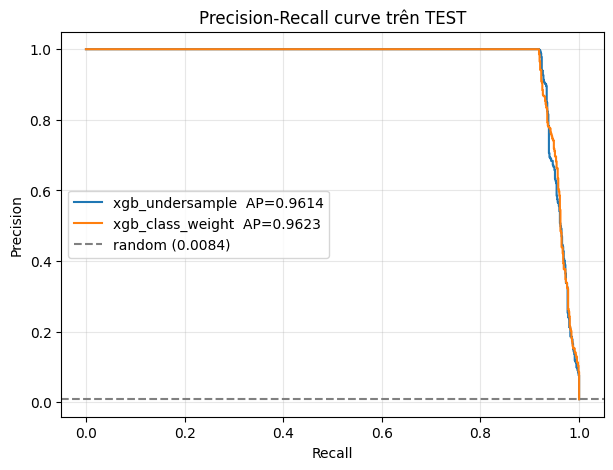

In [47]:
plt.figure(figsize=(7, 5))
for name, model in final_models.items():
    proba_test = model.predict_proba(X_test_sel)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba_test)
    ap = average_precision_score(y_test, proba_test)
    plt.plot(recall, precision, label=f"{name}  AP={ap:.4f}")

# baseline = tỷ lệ fraud trong test
plt.axhline(y_test.mean(), color="gray", linestyle="--", label=f"random ({y_test.mean():.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curve trên TEST")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


### 15.2 Kết luận

- Pick model có **PR-AUC test cao nhất** + **F1/Precision/Recall** đạt yêu cầu nghiệp vụ.
- Nếu chi phí False Negative (bỏ lọt fraud) cao hơn False Positive (gây phiền khách hàng) → ưu tiên **Recall**, dùng threshold thấp.
- Nếu chi phí False Positive cao (phiền khách) → ưu tiên **Precision**, dùng threshold `th_p90`.
- Sau khi chọn model + threshold, có thể save model: `joblib.dump(model, "fraud_model.pkl")`.


<!-- DRIFT_AWARE_CHUNKS_16_SECTION -->
## 15. Đánh giá drift-aware cho `data_chunks_16` - chế độ nhanh

Section này **không train lại model mặc định**. Notebook chỉ đọc kết quả đã chạy sẵn trong `chunk_model_results_16`, phân loại nguyên nhân F1 thấp, rồi vẽ plot tổng hợp.

Nếu cần train lại toàn bộ 15 chunk x 2 model, hãy chạy script riêng `run_xgb_chunks_16_02_16.py` ngoài notebook để tránh block kernel quá lâu.


In [48]:
# DRIFT_AWARE_CHUNKS_16_SECTION
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT_DIR_16 = Path("chunk_model_results_16")
DRIFT_RESULTS_CSV_16 = OUT_DIR_16 / "xgb_chunks_02_16_drift_aware_results.csv"
BASIC_RESULTS_CSV_16 = OUT_DIR_16 / "xgb_chunks_02_16_results.csv"
PLOT_PATH_16 = OUT_DIR_16 / "xgb_chunks_02_16_drift_aware_metrics.png"

problem_chunks_16 = [2, 4, 5, 6, 9, 10, 11]


In [49]:
def classify_issue_16(row: pd.Series) -> str:
    if row["test_fraud_rate"] == 0:
        return "skip_no_positive_test"

    pr_auc_drop = row["val_pr_auc"] - row["test_pr_auc"]
    best_test_f1 = row.get("best_test_f1_diagnostic", np.nan)
    test_f1 = row["test_f1_at_val_threshold"]
    threshold_gap = best_test_f1 - test_f1 if pd.notna(best_test_f1) else np.nan

    if pr_auc_drop >= 0.25 and pd.notna(best_test_f1) and best_test_f1 < 0.50:
        return "concept_or_label_drift_likely"
    if row["test_pr_auc"] >= 0.75 and pd.notna(threshold_gap) and threshold_gap >= 0.25:
        return "threshold_calibration_drift"
    if row["test_pr_auc"] < 0.60:
        return "ranking_drift_suspected"
    if test_f1 < 0.50:
        return "threshold_review_needed"
    return "ok"


if DRIFT_RESULTS_CSV_16.exists():
    results16 = pd.read_csv(DRIFT_RESULTS_CSV_16)
    print(f"Loaded drift-aware cached results: {DRIFT_RESULTS_CSV_16}")
elif BASIC_RESULTS_CSV_16.exists():
    results16 = pd.read_csv(BASIC_RESULTS_CSV_16).rename(columns={
        "threshold_max_f1_val": "threshold_from_val",
        "test_f1": "test_f1_at_val_threshold",
    })
    results16["best_test_threshold_diagnostic"] = np.nan
    results16["best_test_f1_diagnostic"] = np.nan
    results16["best_test_precision_diagnostic"] = np.nan
    results16["best_test_recall_diagnostic"] = np.nan
    print(f"Loaded basic cached results: {BASIC_RESULTS_CSV_16}")
else:
    raise FileNotFoundError(
        "Ch?a c? file k?t qu?. Ch?y trong terminal: python run_xgb_chunks_16_02_16.py"
    )

results16 = results16.copy()
results16["pr_auc_val_to_test_drop"] = results16["val_pr_auc"] - results16["test_pr_auc"]
results16["f1_recoverable_by_threshold"] = (
    results16["best_test_f1_diagnostic"] - results16["test_f1_at_val_threshold"]
)
results16["issue_type"] = results16.apply(classify_issue_16, axis=1)
results16.head()


Loaded drift-aware cached results: chunk_model_results_16\xgb_chunks_02_16_drift_aware_results.csv


,chunk,model,rows,train_inner_size,val_size,test_size,train_inner_fraud_rate,val_fraud_rate,test_fraud_rate,val_pr_auc,test_pr_auc,threshold_from_val,val_f1_at_threshold,test_f1_at_val_threshold,best_test_threshold_diagnostic,best_test_f1_diagnostic,best_test_precision_diagnostic,best_test_recall_diagnostic,test_TN,test_FP,test_FN,test_TP,pr_auc_val_to_test_drop,f1_recoverable_by_threshold,issue_type
0,2,xgb_undersample,536266,35574,85803,107254,0.090909,0.011923,0.007720,0.784373,0.423130,0.911460,0.742111,0.502591,0.924165,0.565818,0.711152,0.469807,105809,617,343,485,0.361243,0.063228,ranking_drift_suspected
1,2,xgb_class_weight,536266,343209,85803,107254,0.009423,0.011923,0.007720,0.833793,0.772613,0.994766,0.798742,0.710947,0.995958,0.736544,0.890411,0.628019,106206,220,250,578,0.061180,0.025597,ok
2,3,xgb_undersample,536266,41734,85803,107254,0.090909,0.010396,0.010219,0.917719,0.921319,0.779572,0.854567,0.854082,0.731730,0.858398,0.923319,0.802007,106131,27,259,837,-0.003600,0.004317,ok
3,3,xgb_class_weight,536266,343209,85803,107254,0.011054,0.010396,0.010219,0.913778,0.910010,0.952051,0.848382,0.843338,0.964786,0.854639,0.982227,0.756387,106069,89,232,864,0.003768,0.011301,ok
4,4,xgb_undersample,536266,39996,85803,107254,0.090909,0.014009,0.008410,0.865333,0.619662,0.715243,0.782123,0.086561,0.917943,0.665325,0.842105,0.549889,90653,15699,151,751,0.245671,0.578765,threshold_review_needed


In [50]:
summary16 = (
    results16[results16["test_fraud_rate"] > 0]
    .groupby("model")[["test_pr_auc", "test_f1_at_val_threshold", "best_test_f1_diagnostic"]]
    .mean()
    .round(4)
)
display(summary16)

cols = [
    "chunk", "model", "val_pr_auc", "test_pr_auc", "pr_auc_val_to_test_drop",
    "threshold_from_val", "test_f1_at_val_threshold", "best_test_f1_diagnostic",
    "f1_recoverable_by_threshold", "issue_type",
]
display(results16[results16["chunk"].isin(problem_chunks_16)][cols].round(4))


,test_pr_auc,test_f1_at_val_threshold,best_test_f1_diagnostic
model,,,
xgb_class_weight,0.8025,0.6031,0.7935
xgb_undersample,0.7736,0.5957,0.7814


,chunk,model,val_pr_auc,test_pr_auc,pr_auc_val_to_test_drop,threshold_from_val,test_f1_at_val_threshold,best_test_f1_diagnostic,f1_recoverable_by_threshold,issue_type
0,2,xgb_undersample,0.7844,0.4231,0.3612,0.9115,0.5026,0.5658,0.0632,ranking_drift_suspected
1,2,xgb_class_weight,0.8338,0.7726,0.0612,0.9948,0.7109,0.7365,0.0256,ok
4,4,xgb_undersample,0.8653,0.6197,0.2457,0.7152,0.0866,0.6653,0.5788,threshold_review_needed
5,4,xgb_class_weight,0.8629,0.5682,0.2946,0.9484,0.0715,0.5996,0.5281,ranking_drift_suspected
6,5,xgb_undersample,0.9558,0.2881,0.6677,0.7146,0.1465,0.3630,0.2165,concept_or_label_drift_likely
7,5,xgb_class_weight,0.9586,0.3500,0.6086,0.9569,0.0966,0.3905,0.2939,concept_or_label_drift_likely
8,6,xgb_undersample,0.9270,0.3268,0.6002,0.7425,0.0798,0.4178,0.3380,concept_or_label_drift_likely
9,6,xgb_class_weight,0.9238,0.4439,0.4799,0.9655,0.0935,0.4757,0.3822,concept_or_label_drift_likely
14,9,xgb_undersample,0.7612,0.7706,-0.0094,0.9113,0.7486,0.7493,0.0007,ok
15,9,xgb_class_weight,0.7184,0.7274,-0.0090,0.9973,0.7427,0.7435,0.0009,ok


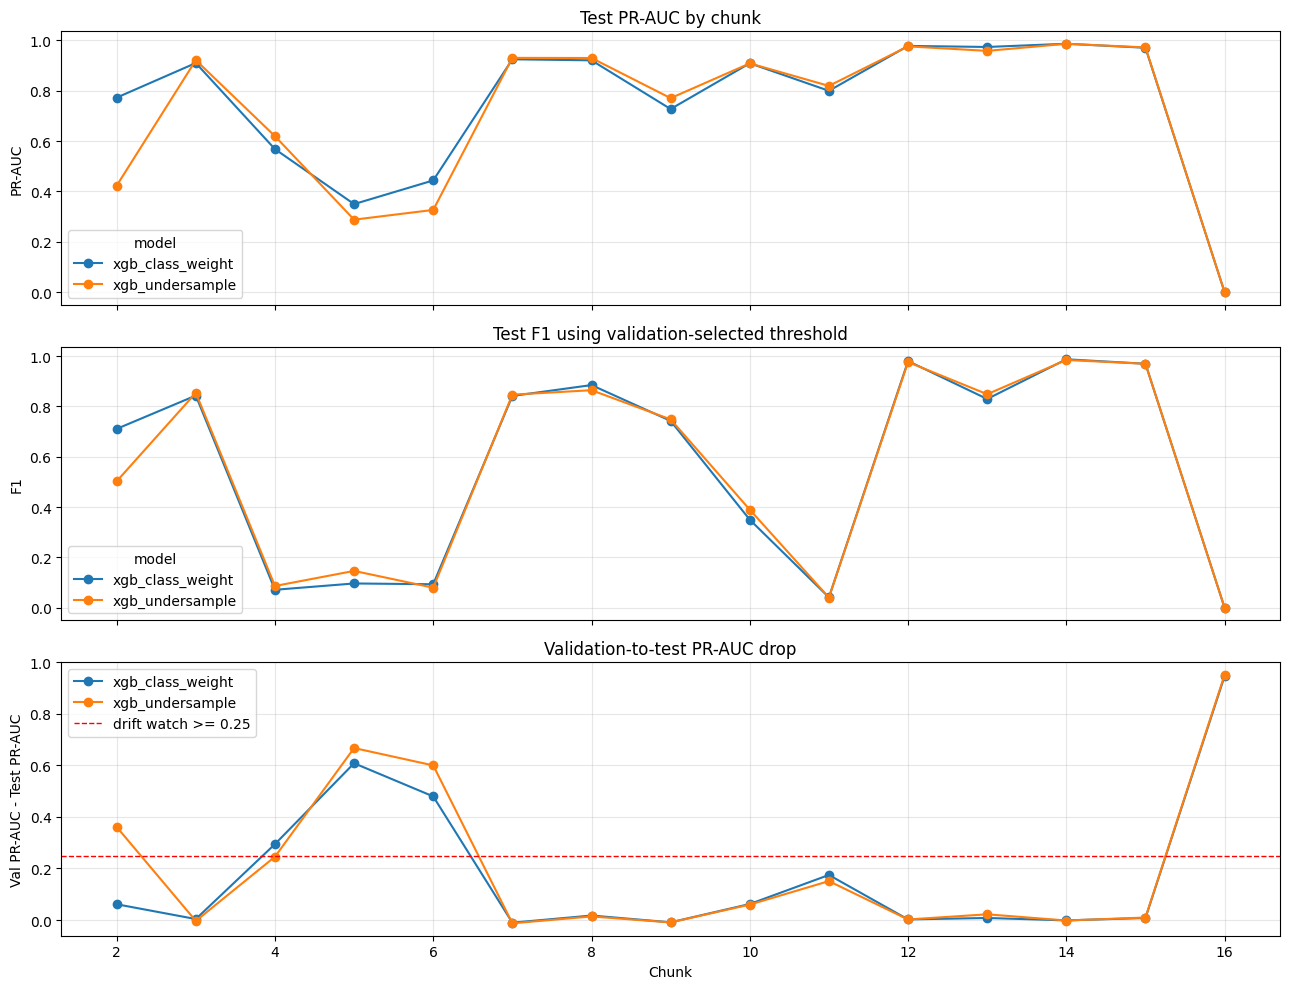

Saved plot: chunk_model_results_16\xgb_chunks_02_16_drift_aware_metrics.png


In [51]:
pivot_pr = results16.pivot(index="chunk", columns="model", values="test_pr_auc")
pivot_f1 = results16.pivot(index="chunk", columns="model", values="test_f1_at_val_threshold")
pivot_gap = results16.pivot(index="chunk", columns="model", values="pr_auc_val_to_test_drop")

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
pivot_pr.plot(ax=axes[0], marker="o")
axes[0].set_title("Test PR-AUC by chunk")
axes[0].set_ylabel("PR-AUC")
axes[0].grid(True, alpha=0.3)

pivot_f1.plot(ax=axes[1], marker="o")
axes[1].set_title("Test F1 using validation-selected threshold")
axes[1].set_ylabel("F1")
axes[1].grid(True, alpha=0.3)

pivot_gap.plot(ax=axes[2], marker="o")
axes[2].axhline(0.25, color="red", linestyle="--", linewidth=1, label="drift watch >= 0.25")
axes[2].set_title("Validation-to-test PR-AUC drop")
axes[2].set_xlabel("Chunk")
axes[2].set_ylabel("Val PR-AUC - Test PR-AUC")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
fig.savefig(PLOT_PATH_16, dpi=150)
try:
    display(fig)
except NameError:
    pass
plt.close(fig)
print(f"Saved plot: {PLOT_PATH_16}")


**Cách đọc kết quả**

- `concept_or_label_drift_likely`: PR-AUC trên test tụt mạnh và ngay cả threshold tốt nhất trên test cũng không cứu được F1. Đây là nhóm nên ưu tiên kiểm tra drift hoặc retrain.
- `threshold_calibration_drift`: PR-AUC trên test vẫn cao nhưng F1 thấp vì threshold chọn từ validation không còn phù hợp với test. Nhóm này nên xử lý bằng threshold động hoặc calibration.
- `ranking_drift_suspected`: model xếp hạng fraud kém trên test. Cần xem lại phân phối feature, pattern nhãn, hoặc dùng rolling retrain.
- `threshold_review_needed`: model chưa tụt PR-AUC nghiêm trọng nhưng F1 thấp; nên kiểm tra lại threshold trước khi kết luận concept drift.
- `skip_no_positive_test`: test set không có giao dịch fraud, nên không dùng chunk đó để kết luận chất lượng model.
